# Deep Learning — Minimal Example

Building a simple machine-learning algorithm **from scratch with NumPy**: generate data,
define a linear model, an L2-norm loss, and use **gradient descent** to learn the weights
and bias.

Ties directly to the course notes (four ingredients, the linear model, L2 loss, gradient
descent). — Waheed

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
## creating fake data to compare
observations = 1000

## next function basically draws a random value from the interval (low,high) where each number has an equal chance of being selected.
xs = np.random.uniform(low = -10,high=10,size = (observations,1))
zs = np.random.uniform(-10,10,(observations,1))

inputs = np.column_stack((xs,zs)) ## stacks the osbervations into a matrix

print(inputs.shape)

(1000, 2)


In [3]:
## Creating the targets we will aim at

noise = np.random.uniform(-1,1,(observations,1))
targets = 13*xs + 7*zs - 12 + noise
print(targets.shape)

(1000, 1)


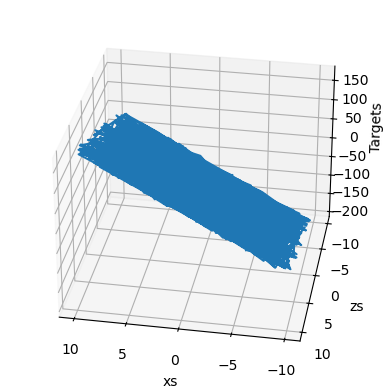

In [4]:
targets = targets.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection ='3d')
ax.plot(xs.reshape(observations,),zs.reshape(observations,), targets.reshape(observations,))
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim = 100)
plt.show()
targets = targets.reshape(observations,1)

In [5]:
## initiating a variable that will have the initial weights and biases that will be picked randomly from an interval of -0.1 and 0.1
init_range = 0.1
weights = np.random.uniform(-init_range,init_range,size=(2,1))
biases = np.random.uniform(-init_range,init_range,size=1)
print(weights)
print(biases)

[[-0.08013666]
 [ 0.0760971 ]]
[0.01403475]


## Setting a learning rate and training our model

In [6]:
learning_rate = 0.03
for i in range (300):
    outputs = np.dot(inputs,weights) + biases ## this is essentially the y = xw + b formula (the np.dot function is just there to multiply two matrices)
    deltas = outputs - targets ## just a variable to indicate the difference between outputs and targets
    loss = np.sum((deltas**2)) / observations
    print (loss)

    deltas_scaled = deltas / observations

    ##gradient descent logic
    weights = weights - learning_rate * np.dot(inputs.T,deltas_scaled) ## Since weights are 2x1 and inputs are 1000x2 we cannot multiply unless we transpose the inputs
    biases = biases - learning_rate * np.sum(deltas_scaled)

7401.592434616191
144.38419212610478
129.85030428448883
122.20323166307172
115.01338420673777
108.24771202746666
101.88118379819099
95.89025182945272
90.25275764713271
84.9478500264932
79.95590787038844
75.25846763732133
70.83815505091603
66.67862083822094
62.764480259160294
59.08125620347403
55.61532564467884
52.353869253003595
49.28482398093188
46.39683844598259
43.67923094570417
41.121949949593095
38.71553692180999
36.45109133718695
34.32023776113122
32.315094871665195
30.428246309025685
28.65271324500401
26.981928570570975
25.409712606314294
23.930250245850498
22.53806944767116
21.228020995872974
19.995259454912773
18.835225247945356
17.743627792458263
16.716429630827335
15.749831497097608
14.840258264756207
13.984345723522889
13.178928136249938
12.421026529908403
11.707837677353101
11.036723729113273
10.405202456860792
9.81093807246908
9.251732588706298
8.72551768960804
8.23034708046133
7.76438928910482
7.325920891919485
6.9133201394552515
6.5250609581165655
6.159707305721463
5.81

In [7]:
## Printing the weights and biases and see if we have worked correctly comparing it to 2*xs - 3*zs + 5 + noise
print (weights,biases)

[[12.99820362]
 [ 7.00144054]] [-11.97965729]


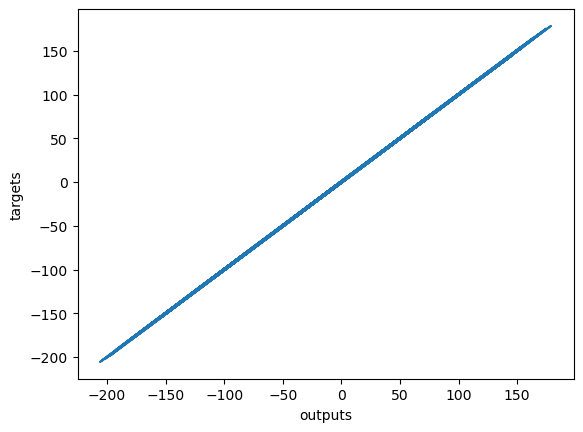

In [8]:
plt.plot(outputs,targets)
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()